# Notebook 03 — Scoring, Affordability & Regression
## The 15-Minute Shanghai Project · Track C — Affordability

This notebook turns the per-hexagon accessibility computed in notebook 02 into (i) a **weighted accessibility index**,
(ii) an **affordability cross-analysis** that is the heart of Track C, and (iii) a **hedonic regression** testing
whether 15-minute access is *capitalised into housing prices* — the empirical core of the equity question raised by
Weng et al. (2019).

**Research question.** *Is 15-minute access in Shanghai a privilege of the wealthy, or do "accessible-and-affordable"
corridors exist?*

## 1. Setup & load

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, geopandas as gpd, h3
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from config import DATA_CLEAN, OUTPUTS
warnings.filterwarnings("ignore")
WGS84 = "EPSG:4326"
NEEDS = ["alimentation", "sante", "education", "emploi", "loisir_sport", "services"]

hexes = gpd.read_parquet(DATA_CLEAN / "hexes.parquet")
prices = gpd.read_parquet(DATA_CLEAN / "prices.parquet")
print(f"Hexagones: {len(hexes):,} | Points de prix: {len(prices):,}")

Hexagones: 12,106 | Points de prix: 27,471


## 2. Weighted accessibility index
The baseline count (0–6) treats walking and cycling equally. For a **15-minute *walkable* city**, walking is the gold
standard: it is universal (children, elderly, mobility-restricted), zero-cost, and the most equity-relevant mode —
exactly the populations Weng et al. (2019) find under-served. We therefore weight a need **1.0 if reachable on foot**
and **0.5 if only reachable by bike**, and rescale to 0–100:

$$\text{access\_index} = \frac{100}{6}\sum_{\text{need}} \begin{cases}1.0 & \text{walk} \\ 0.5 & \text{bike only} \\ 0 & \text{neither}\end{cases}$$

In [2]:
acc = np.zeros(len(hexes))
for need in NEEDS:
    acc += np.where(hexes[f"walk_{need}"], 1.0, np.where(hexes[f"bike_{need}"], 0.5, 0.0))
hexes["access_index"] = (100 * acc / 6).round(1)
print(hexes["access_index"].describe().round(1).to_string())

count    12106.0
mean        76.2
std         24.3
min          0.0
25%         66.7
50%         83.3
75%        100.0
max        100.0


## 3. Aggregate housing prices to hexagons
Each price point is binned to its H3 cell; the per-hexagon price is the **median ¥/m²** (robust to outliers).

In [3]:
pts = prices.geometry.representative_point()
prices = prices.assign(lng=pts.x.values, lat=pts.y.values)
prices["cell"] = [h3.latlng_to_cell(la, lo, 8) for la, lo in zip(prices["lat"], prices["lng"])]
agg = prices.groupby("cell")["price_per_m2"].median()
cnt = prices.groupby("cell").size()
hexes["price_per_m2"] = hexes["cell"].map(agg)
hexes["n_price"] = hexes["cell"].map(cnt).fillna(0).astype(int)
cov = hexes["price_per_m2"].notna().mean()
print(f"Hexagones avec donnée de prix : {hexes['price_per_m2'].notna().sum():,} ({100*cov:.0f}%)")
print(hexes["price_per_m2"].describe().round(0).to_string())

Hexagones avec donnée de prix : 2,989 (25%)


count      2989.0
mean      44209.0
std       25409.0
min        2584.0
25%       25798.0
50%       40489.0
75%       58874.0
max      273128.0


## 4. Affordability × accessibility — the Track C typology
Crossing the two dimensions at their medians yields four neighbourhood types. The policy-relevant cell is
**Accessible & affordable** — the corridors that deliver the 15-minute ideal *without* a wealth premium. We also build
a continuous **value score** = (accessibility percentile − price percentile): positive means a hexagon offers *more
access than its price would predict*.

In [4]:
hd = hexes.dropna(subset=["price_per_m2"]).copy()
amed, pmed = hd["access_index"].median(), hd["price_per_m2"].median()

def classify(r):
    acc_hi = r["access_index"] >= amed
    aff = r["price_per_m2"] <= pmed
    if acc_hi and aff:   return "Accessible & abordable"
    if acc_hi and not aff: return "Privilégié (cher)"
    if not acc_hi and aff: return "Abordable mais enclavé"
    return "Enclavé & cher"

hexes["afford_type"] = hd.apply(classify, axis=1).reindex(hexes.index)
hexes["access_pct"] = hexes["access_index"].rank(pct=True) * 100
hexes.loc[hd.index, "price_pct"] = hd["price_per_m2"].rank(pct=True) * 100
hexes["value_score"] = (hexes["access_pct"] - hexes["price_pct"]).round(1)

print(f"Médianes — accessibilité {amed:.0f}/100 | prix {pmed:,.0f} ¥/m²\n")
print(hexes["afford_type"].value_counts().to_string())

Médianes — accessibilité 100/100 | prix 40,489 ¥/m²

afford_type
Privilégié (cher)         1270
Accessible & abordable    1001
Abordable mais enclavé     494
Enclavé & cher             224


## 5. Regression — is access capitalised into price?
Hedonic OLS on Anjuke listings (which carry a precomputed metro distance). We add the hexagon `access_index` to the
prior project's price~metro-distance model and test whether access carries an independent, positive price premium.

In [5]:
anj = prices[prices["source"] == "anjuke"].copy()
idx = hexes.set_index("cell")
anj["access_index"] = anj["cell"].map(idx["access_index"])
anj = anj.dropna(subset=["price_per_m2", "dist_metro_m", "access_index"])
anj["log_price"] = np.log(anj["price_per_m2"])
anj["metro_km"] = anj["dist_metro_m"] / 1000

m1 = smf.ols("log_price ~ metro_km", anj).fit()
m2 = smf.ols("log_price ~ metro_km + access_index", anj).fit()
m3 = smf.ols("log_price ~ metro_km + access_index + C(adname)", anj).fit()
print(f"n = {len(anj):,} logements Anjuke\n")
print(f"{'Modèle':<34}{'R²':>8}{'β metro_km':>14}{'β access':>12}")
for name, m in [("1. prix~métro", m1), ("2. +accessibilité", m2), ("3. +district (FE)", m3)]:
    bm = m.params.get("metro_km", float('nan'))
    ba = m.params.get("access_index", float('nan'))
    print(f"{name:<34}{m.rsquared:>8.3f}{bm:>14.4f}{ba:>12.4f}")
print("\nModèle 2 — significativité :")
print(m2.summary().tables[1])

n = 9,741 logements Anjuke

Modèle                                  R²    β metro_km    β access
1. prix~métro                        0.143       -0.1796         nan
2. +accessibilité                    0.144       -0.1765      0.0029
3. +district (FE)                    0.569       -0.0785      0.0010

Modèle 2 — significativité :
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.6310      0.080    132.862      0.000      10.474      10.788
metro_km        -0.1765      0.005    -38.810      0.000      -0.185      -0.168
access_index     0.0029      0.001      3.551      0.000       0.001       0.004


## 6. Maps — price, typology, value

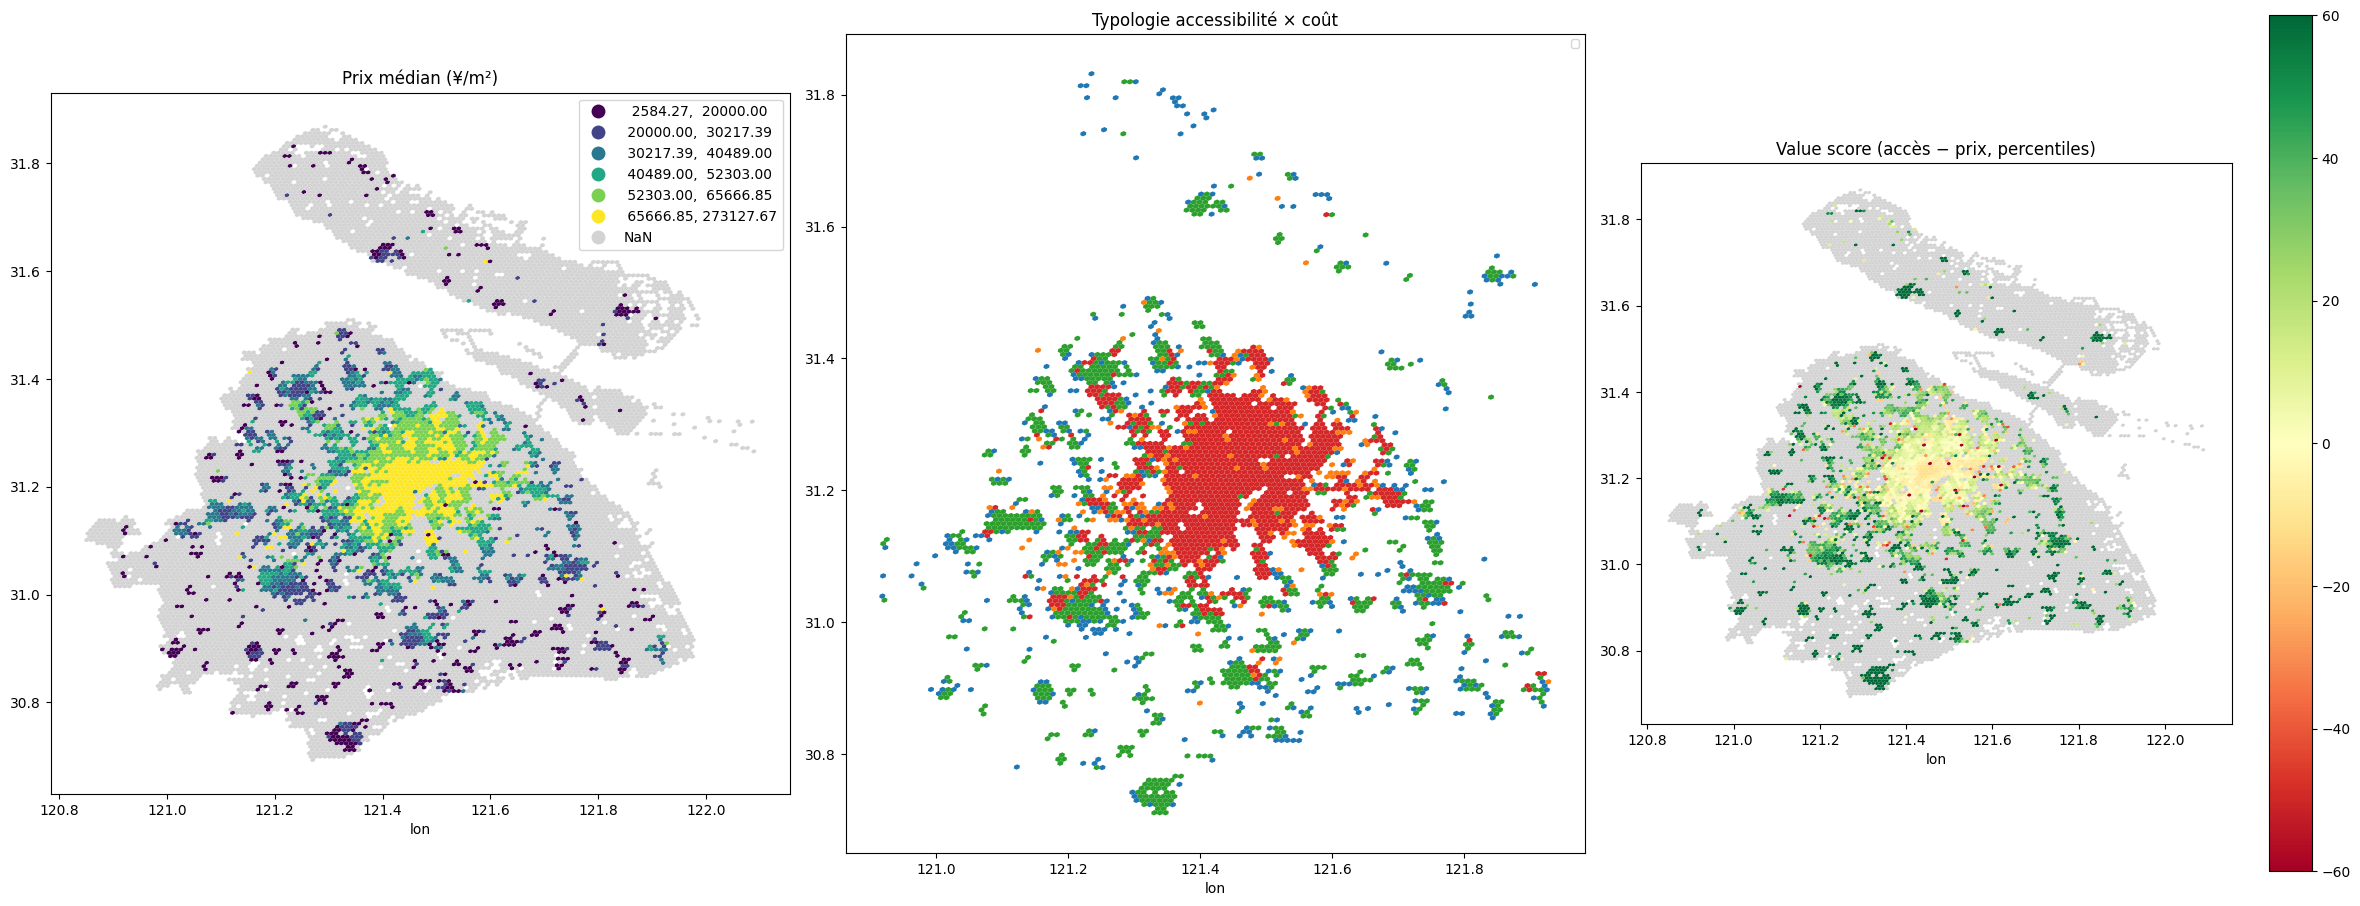

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
hexes.plot(column="price_per_m2", cmap="viridis", scheme="quantiles", k=6,
           legend=True, linewidth=0, ax=axes[0], missing_kwds={"color": "lightgrey"})
axes[0].set_title("Prix médian (¥/m²)")

colors = {"Accessible & abordable": "#2ca02c", "Privilégié (cher)": "#d62728",
          "Abordable mais enclavé": "#1f77b4", "Enclavé & cher": "#ff7f0e"}
for t, c in colors.items():
    sub = hexes[hexes["afford_type"] == t]
    if len(sub): sub.plot(color=c, linewidth=0, ax=axes[1], label=t)
axes[1].legend(fontsize=8, loc="upper right"); axes[1].set_title("Typologie accessibilité × coût")

hexes.plot(column="value_score", cmap="RdYlGn", vmin=-60, vmax=60, legend=True,
           linewidth=0, ax=axes[2], missing_kwds={"color": "lightgrey"})
axes[2].set_title("Value score (accès − prix, percentiles)")
for ax in axes: ax.set_aspect("equal"); ax.set_xlabel("lon")
plt.tight_layout(); plt.show()

## 7. "Where to live" — top accessible-and-affordable corridors
Hexagons with full or near-full access *and* below-median price, ranked by value score.

In [7]:
best = hexes[(hexes["afford_type"] == "Accessible & abordable")].copy()
best = best.sort_values("value_score", ascending=False)
cols = ["cell", "access_index", "price_per_m2", "value_score", "n_price"]
print(f"Corridors 'accessible & abordable' : {len(best):,} hexagones")
print("\nTop 12 (meilleur rapport accès/prix) :")
print(best[cols].head(12).to_string(index=False))

Corridors 'accessible & abordable' : 1,001 hexagones

Top 12 (meilleur rapport accès/prix) :
           cell  access_index  price_per_m2  value_score  n_price
883099486dfffff         100.0   5374.920736         87.2        1
88309b95d9fffff         100.0   5411.764706         87.2        1
88309b89a1fffff         100.0   6671.000000         87.0        1
88309b99a3fffff         100.0   7875.000000         86.7        1
883099d42dfffff         100.0   8273.313692         86.4        2
88309bc645fffff         100.0   8333.000000         86.4        1
8830994495fffff         100.0   8807.884862         86.3        2
883099d5b9fffff         100.0   8604.000000         86.3        5
88309b1043fffff         100.0   8741.074122         86.3        2
8830990a99fffff         100.0   8856.989561         86.2        4
88309d6a9dfffff         100.0   9070.000000         86.1        2
88309d699bfffff         100.0   9163.947368         86.0        2


## 8. Export enriched grid
The final `hexes.geojson` (now with access index, price, typology, value score) powers the Streamlit app.

In [8]:
keep = (["cell", "clat", "clng", "baseline_score", "n_walk", "n_bike", "access_index",
         "price_per_m2", "n_price", "afford_type", "value_score"]
        + [f"acc_{n}" for n in NEEDS])
out = hexes[keep + ["geometry"]].copy()
out.to_file(OUTPUTS / "hexes.geojson", driver="GeoJSON")
out.to_parquet(DATA_CLEAN / "hexes_scored.parquet")
print("Exporté:")
for f in [OUTPUTS / "hexes.geojson", DATA_CLEAN / "hexes_scored.parquet"]:
    print(f"  {f.name:24} {f.stat().st_size/1e6:6.2f} MB | {len(out):,} hexagones")
print("\nColonnes finales:", list(out.columns))

Exporté:
  hexes.geojson              9.51 MB | 12,106 hexagones
  hexes_scored.parquet       1.69 MB | 12,106 hexagones

Colonnes finales: ['cell', 'clat', 'clng', 'baseline_score', 'n_walk', 'n_bike', 'access_index', 'price_per_m2', 'n_price', 'afford_type', 'value_score', 'acc_alimentation', 'acc_sante', 'acc_education', 'acc_emploi', 'acc_loisir_sport', 'acc_services', 'geometry']
